## <u>Importing the Libraries Used : </u>
#### Data Handling & Manipulation
- pandas: Data manipulation and analysis.
- numpy: Numerical computations and array operations.
- collections.Counter: For counting class distributions.
#### Machine Learning Components (Scikit-Learn)
- train_test_split: Splitting the dataset for training \ testing.
- cross_val_score, StratifiedKFold: For cross-validation.
- MinMaxScaler: Feature scaling \ normalization.
- LabelEncoder: Encoding categorical labels.
#### Evaluation Metrics (Scikit-Learn)
confusion_matrix, accuracy_score, f1_score, recall_score, precision_score, roc_curve, auc, and roc_auc_score.
#### Model and Algorithm (Scikit-Learn)
- OneVsRestClassifier: Multi-class classification strategy.
- RandomForestClassifier: Ensemble tree-based classifier.
#### Visualization and Saving
- matplotlib.pyplot: Basic plotting and visualization.
- seaborn: Enhanced statistical visualizations.
- plot_tree: Individual decision tree visualization.
- pickle: Model saving.


In [125]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, precision_score, roc_curve, auc, roc_auc_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from collections import Counter 
import seaborn as sns
import pickle

## <u> Data Setup : </u>
We begin by importing dataset ("obesity.csv") and performing basic exploratory analysis.

We applied the following preprocessing steps:
The features <b>(X)</b> will be created by taking all columns except the final one, which we will assign as our target variable <b>(y)</b>, "NObeyesdad", so we are prepared for a supervised classification task.


In [126]:
df = pd.read_csv('obesity.csv')
print(df.head())
print("\nShape of the dataset:",df.shape)
print("\nOutput Grouping: ",df.groupby("NObeyesdad").size())

# Data preprocessing
X = df.iloc[:, :-1].copy()
y = df.iloc[:, -1].copy()

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

## <u>Handling Missing Values : </u>
The dataset contains both categorical and numerical features.

We remove any rows with missing entries to ensure data quality for model training.

In our dataset, this step confirmed that no missing values were present, as the row count remained unchanged after applying the operation.

In [127]:
df = df.dropna() 

## <u>Encoding : </u> 

In order to transform our category variables into a numerical format that machine learning algorithms can use, we continue by encoding them.

The preprocessing procedures listed below are used:


All categorical features in the feature set (X) and the target variable (y) are transformed using Label Encoding. For certain columns, such as gender, family history, food preferences, and modes of transportation, the same encoding procedure is immediately applied to the main dataframe.

To ensure mapping integrity, we construct and keep encoder objects, which enable us to monitor the process of converting each category to its numerical representation. This guarantees that during the training and classification stages, our model can accurately understand the encoded features.

In [128]:
for col in X.columns:  
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

le_target = LabelEncoder()
y = le_target.fit_transform(y)

categorical_columns = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 
                      'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  


for col, encoder in encoders.items():
    print(f"\n{col} mapping:")
    for i, class_name in enumerate(encoder.classes_):
        print(f"  {class_name} -> {i}")
    



Gender mapping:
  Female -> 0
  Male -> 1

family_history_with_overweight mapping:
  no -> 0
  yes -> 1

FAVC mapping:
  no -> 0
  yes -> 1

CAEC mapping:
  Always -> 0
  Frequently -> 1
  Sometimes -> 2
  no -> 3

SMOKE mapping:
  no -> 0
  yes -> 1

SCC mapping:
  no -> 0
  yes -> 1

CALC mapping:
  Always -> 0
  Frequently -> 1
  Sometimes -> 2
  no -> 3

MTRANS mapping:
  Automobile -> 0
  Bike -> 1
  Motorbike -> 2
  Public_Transportation -> 3
  Walking -> 4

NObeyesdad mapping:
  Insufficient_Weight -> 0
  Normal_Weight -> 1
  Obesity_Type_I -> 2
  Obesity_Type_II -> 3
  Obesity_Type_III -> 4
  Overweight_Level_I -> 5
  Overweight_Level_II -> 6


## <u>Train - Test Split : </u> 
A 70-30 split is used to divide the data, with 30% set aside for testing and 70% of the instances assigned to the training set. The reproducibility of this split between runs is guaranteed by a fixed random state.

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## <u> Normalization / Scaling : </u>
To convert all feature values into a uniform range between 0 and 1, we employ Min-Max scaling. To avoid data leakage, the scaler is only fitted on the training data before applying the same transformation parameters to both the training and test sets.

In [130]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## <u> Visualization : </u>
This process helps us comprehend the central tendency and dispersion of our feature values by providing a statistical summary that includes count, mean, standard deviation, lowest and maximum values, and quartiles for every numerical column in the dataset.

In [131]:
print(df.describe())

            Gender          Age       Height       Weight  \
count  2111.000000  2111.000000  2111.000000  2111.000000   
mean      0.505921    24.312600     1.701677    86.586058   
std       0.500083     6.345968     0.093305    26.191172   
min       0.000000    14.000000     1.450000    39.000000   
25%       0.000000    19.947192     1.630000    65.473343   
50%       1.000000    22.777890     1.700499    83.000000   
75%       1.000000    26.000000     1.768464   107.430682   
max       1.000000    61.000000     1.980000   173.000000   

       family_history_with_overweight         FAVC         FCVC          NCP  \
count                     2111.000000  2111.000000  2111.000000  2111.000000   
mean                         0.817622     0.883941     2.419043     2.685628   
std                          0.386247     0.320371     0.533927     0.778039   
min                          0.000000     0.000000     1.000000     1.000000   
25%                          1.000000     1.000000

Highly linked variables that could affect model performance can be found by using a correlation heatmap, which shows the pairwise correlations between all features. In order to show how feature values differ between target groups and possibly discover significant predictors, we also create boxplots that compare the distribution of each numerical feature across the various obesity classes.

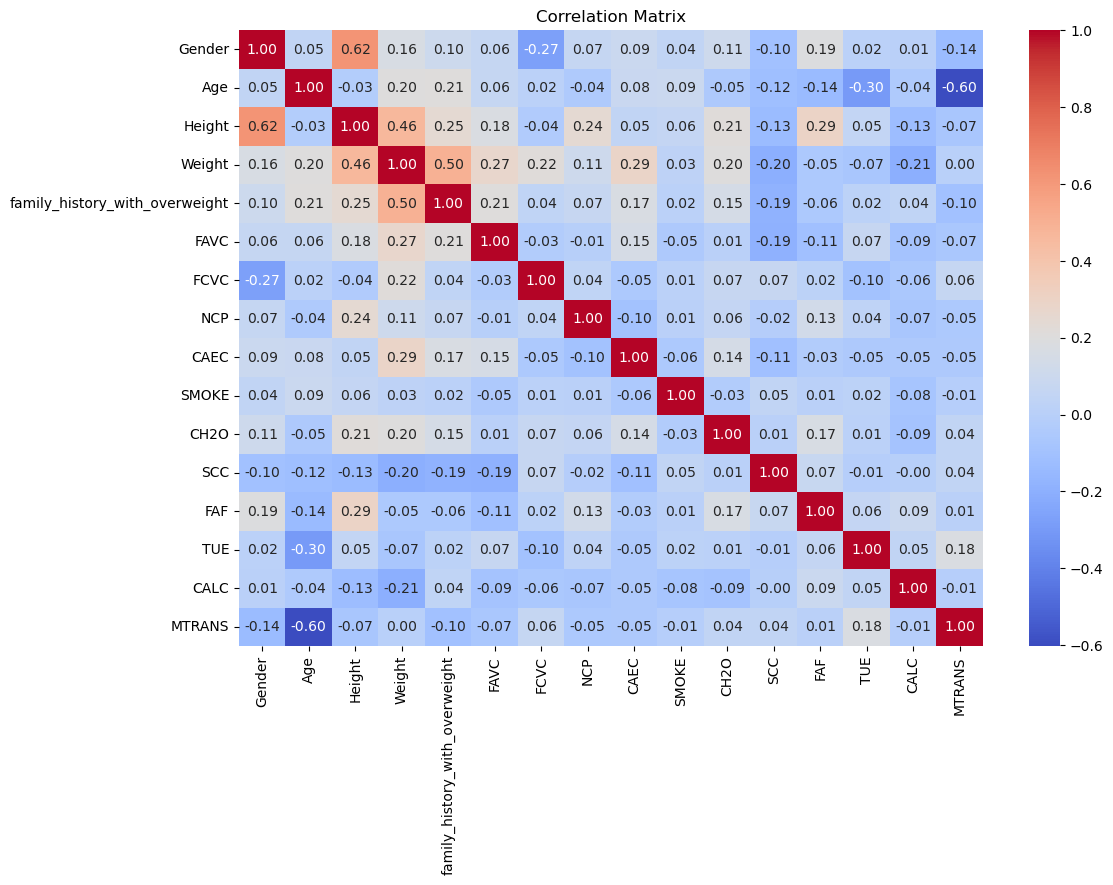

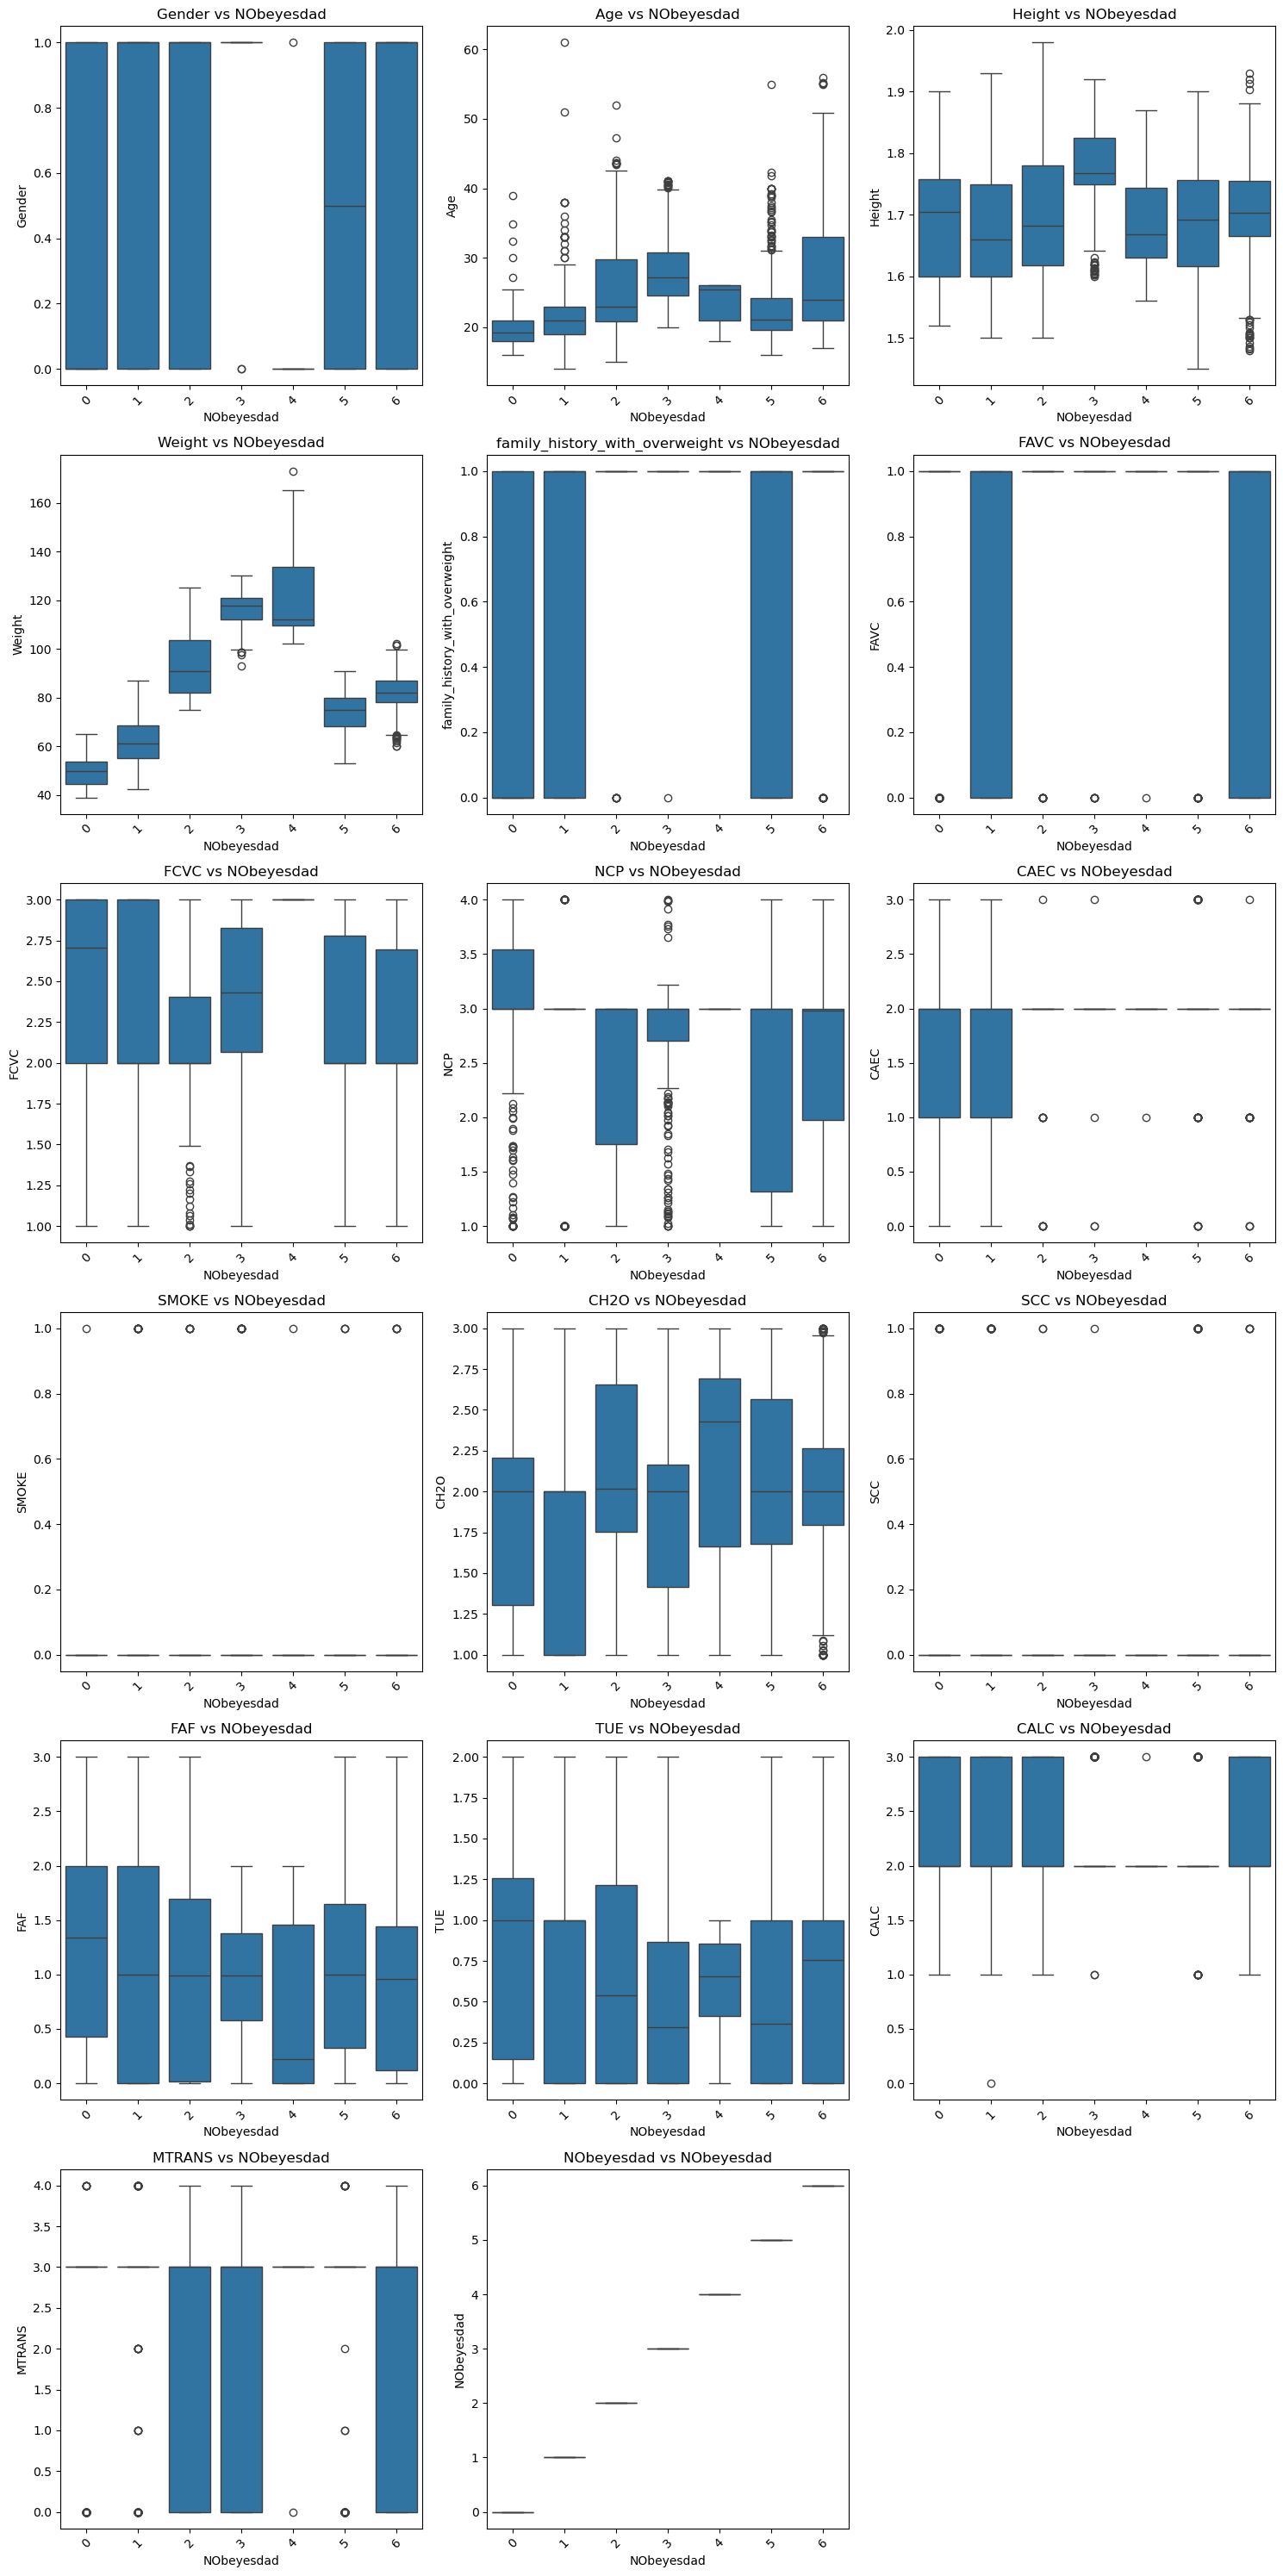

In [132]:
#HEATMAP 
plt.figure(figsize=(12, 8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

#BOXPLOT 
numerical_features = df.select_dtypes(include=['int64','float64']).columns

num_features = len(numerical_features)
cols = 3
rows = (num_features // cols) + (num_features % cols > 0)

plt.figure(figsize=(15, 5*rows))
for i, feature in enumerate(numerical_features):
    plt.subplot(rows, cols, i+1)
    sns.boxplot(x='NObeyesdad', y=feature, data=df)
    plt.title(f'{feature} vs NObeyesdad')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## <u> K-Nearest Neighbors (KNN) Classifier : </u>
#### Model Implentation
Both Euclidean and Manhattan distance metrics are supported by our unique KNN class, which also permits adjustable neighborhood size. Core techniques for model training, class prediction using majority vote among closest neighbors, and probability estimate based on class distribution within the chosen neighborhood are all included in the implementation.



In [133]:
class MyKNN:
    def __init__(self, k=7,distance="euclidean"):
        self.k = k
        self.distance = distance

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        y_pred = []
        for x in X_test:
            if self.distance == "euclidean":
                distances = np.linalg.norm(self.X_train - x, axis=1)
            elif self.distance == "manhattan":
                distances = np.sum(np.abs(self.X_train - x),axis=1)

            nearest_indices = np.argsort(distances)[:self.k]
            nearest_labels = self.y_train[nearest_indices]
            label = Counter(nearest_labels).most_common(1)[0][0]
            y_pred.append(label)
        return np.array(y_pred)

    def predict_proba(self, X_test):
        proba = []
        for x in X_test:
            if self.distance == "euclidean":
                distances = np.linalg.norm(self.X_train - x, axis=1)
            elif self.distance == "manhattan":
                distances = np.sum(np.abs(self.X_train - x), axis=1)

            nearest_indices = np.argsort(distances)[:self.k]
            nearest_labels = self.y_train[nearest_indices]
            
            # Calculate probabilities based on class frequencies in neighbors
            class_counts = Counter(nearest_labels)
            total_neighbors = len(nearest_labels)
            class_probs = []
            
            for class_label in np.unique(self.y_train):
                class_probs.append(class_counts.get(class_label, 0) / total_neighbors)
            proba.append(class_probs)
        
        return np.array(proba)

In [134]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

#### Hyperparameter Tuning 
To find the best parameters for our KNN model, we conduct a thorough <b>grid search</b>. To ensure reliable performance estimation, we evaluate several neighborhood sizes and distance metrics using stratified k-fold cross-validation.

In [135]:
param_grid = {
    'k': [3, 5, 7, 9, 11],
    'distance': ['euclidean', 'manhattan']
}
best_score = 0
best_params = {}
k_fold = StratifiedKFold(n_splits=5, shuffle=True)

print("\nPerforming Grid Search with Cross-Validation...")
for k in param_grid['k']:
    for distance in param_grid['distance']:
        fold_scores = []
        
        for train_idx, val_idx in k_fold.split(X_train, y_train):
            X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
            
            model = MyKNN(k=k, distance=distance)
            model.fit(X_fold_train, y_fold_train)
            y_fold_pred = model.predict(X_fold_val)
            score = accuracy_score(y_fold_val, y_fold_pred)
            fold_scores.append(score)
        
        mean_score = np.mean(fold_scores)
        print(f"k={k}, distance={distance}: Accuracy = {mean_score:.4f}")
        
        if mean_score > best_score:
            best_score = mean_score
            best_params = {'k': k, 'distance': distance}

print(f"\nBest Parameters: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")


Performing Grid Search with Cross-Validation...
k=3, distance=euclidean: Accuracy = 0.7867
k=3, distance=manhattan: Accuracy = 0.8470
k=5, distance=euclidean: Accuracy = 0.7799
k=5, distance=manhattan: Accuracy = 0.8402
k=7, distance=euclidean: Accuracy = 0.7563
k=7, distance=manhattan: Accuracy = 0.8226
k=9, distance=euclidean: Accuracy = 0.7366
k=9, distance=manhattan: Accuracy = 0.8070
k=11, distance=euclidean: Accuracy = 0.7231
k=11, distance=manhattan: Accuracy = 0.8050

Best Parameters: {'k': 3, 'distance': 'manhattan'}
Best Cross-Validation Accuracy: 0.8470


#### Model Training
The final model for evaluation is created by executing the custom KNN classifier with the best-performing parameters and training it on the entire training dataset.

In [136]:
final_model = MyKNN(k=best_params['k'], distance=best_params['distance'])
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

#### Performance Evaluation
We evaluate the model's performance using a variety of metrics on the test set, offering a thorough understanding of classification performance across several measurement dimensions.

The model's prediction patterns are visually represented by a confusion matrix heatmap that shows class-wise performance and possible misclassification trends between various obesity categories.

Accuracy of KNN: 0.8580
F1 Score of KNN: 0.8554
Recall of KNN: 0.8580
Precision of KNN: 0.8564
Confusion Matrix:
 [[79  5  0  0  0  1  1]
 [12 57  8  0  0  7  9]
 [ 1  2 92  2  0  2  3]
 [ 0  0  2 85  0  0  1]
 [ 0  1  0  0 97  0  0]
 [ 2  9  3  0  0 67  7]
 [ 0  2  3  1  1  5 67]]
Type of onfusion matrix: <class 'numpy.ndarray'>


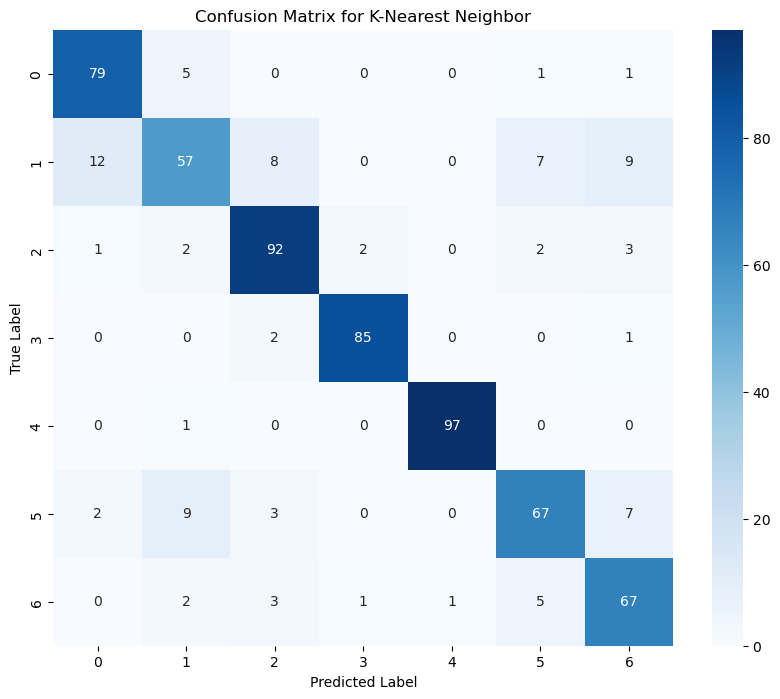

In [137]:
conf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted') 
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred,average = "weighted")
precision = precision_score(y_test,y_pred,average = "weighted")

print(f"Accuracy of KNN: {accuracy:.4f}")
print(f"F1 Score of KNN: {f1:.4f}")
print(f"Recall of KNN: {recall:.4f}")
print(f"Precision of KNN: {precision:.4f}")
#Building confusion matrix:

print("Confusion Matrix:\n", conf_matrix)
print("Type of onfusion matrix:", type(conf_matrix))
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for K-Nearest Neighbor")
plt.show()


#### ROC & AUC Analysis 
Using a one-versus-rest method, we perform a thorough <b>Receiver Operating Characteristic (ROC)</b> analysis to assess the model's discriminative power across all obesity categories.

In order to evaluate per-category classification performance, probability predictions are produced for the test set, allowing ROC curves and AUC scores to be calculated for each individual class.

Plotting ROC curves for each class together with their corresponding AUC values allows for a clear visual comparison of how well the model distinguishes each form of obesity from the others.

To provide a single, comprehensive metric that summarizes the model's overall discriminative power across the multi-class classification job, the macro-average AUC score is calculated.



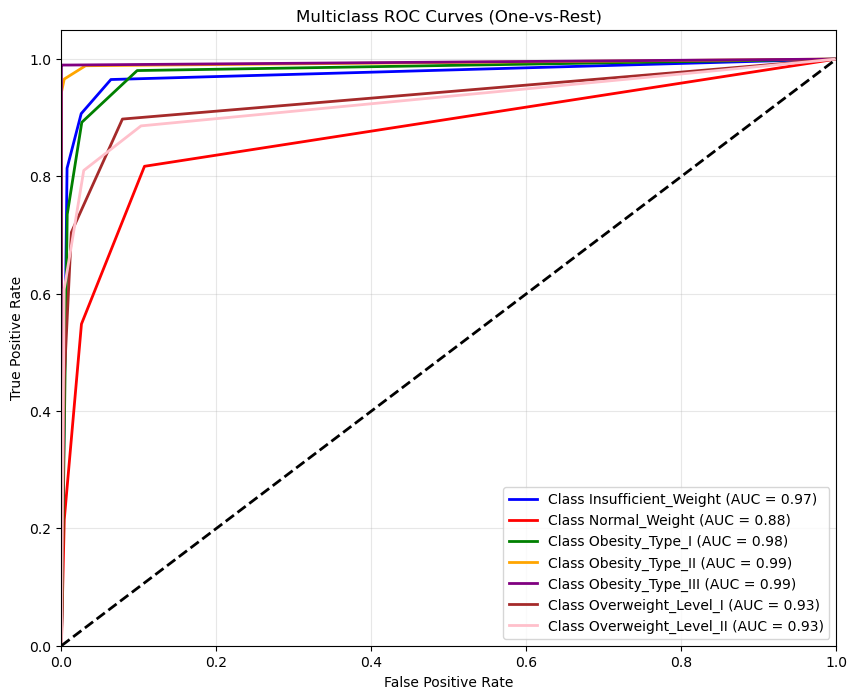

Macro-average AUC: 0.9540


In [138]:
y_proba = final_model.predict_proba(X_test)

# Calculate ROC curve and AUC for each class
n_classes = len(np.unique(y))
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)], 
             lw=2, label=f'Class {le_target.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
macro_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
print(f"Macro-average AUC: {macro_auc:.4f}")

## <u> Random Forest Model : </u>
#### Optimization of Hyperparameters
In order to effectively explore the vast parameter space of the Random Forest technique while striking a balance between computing efficiency and thorough parameter coverage, I applied <b>randomized search</b> with cross-validation.
#### Training and Assessment of Models
The test dataset is used to train and assess the top-performing Random Forest configuration found during the search process. Extensive performance measures are computed to evaluate the efficiency of the classification.

In [139]:
#  Using Random Forest 
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5, 0.7,0.8],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}


print("Performing Randomized Search...")
random_search = RandomizedSearchCV(
    estimator= RandomForestClassifier(random_state = 42),
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter combinations to try
    cv=5,       # 5-fold cross-validation
    scoring='accuracy',
    #random_state = 42
    n_jobs=-1,  # Use all available cores
    verbose=1
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)
print("Best Cross-validation Score:", random_search.best_score_)

y_pred_forRF = best_rf.predict(X_test)

Performing Randomized Search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20, 'criterion': 'entropy', 'bootstrap': True}
Best Cross-validation Score: 0.9675034356390289


#### Interpretability of the Model
To improve knowledge of feature importance in obesity categorization and to provide light on the model's decision-making process, I have showed many distinct decision trees from the ensemble.

#### Evaluation of Performance
The categorization trends and misclassifications across the many obesity categories in the used dataset are clearly interpreted through the creation and visualization of a comprehensive confusion matrix.

Accuracy of RF: 0.9543
F1 Score of RF: 0.9542
Recall of RF: 0.9543
Precision of RF: 0.9546


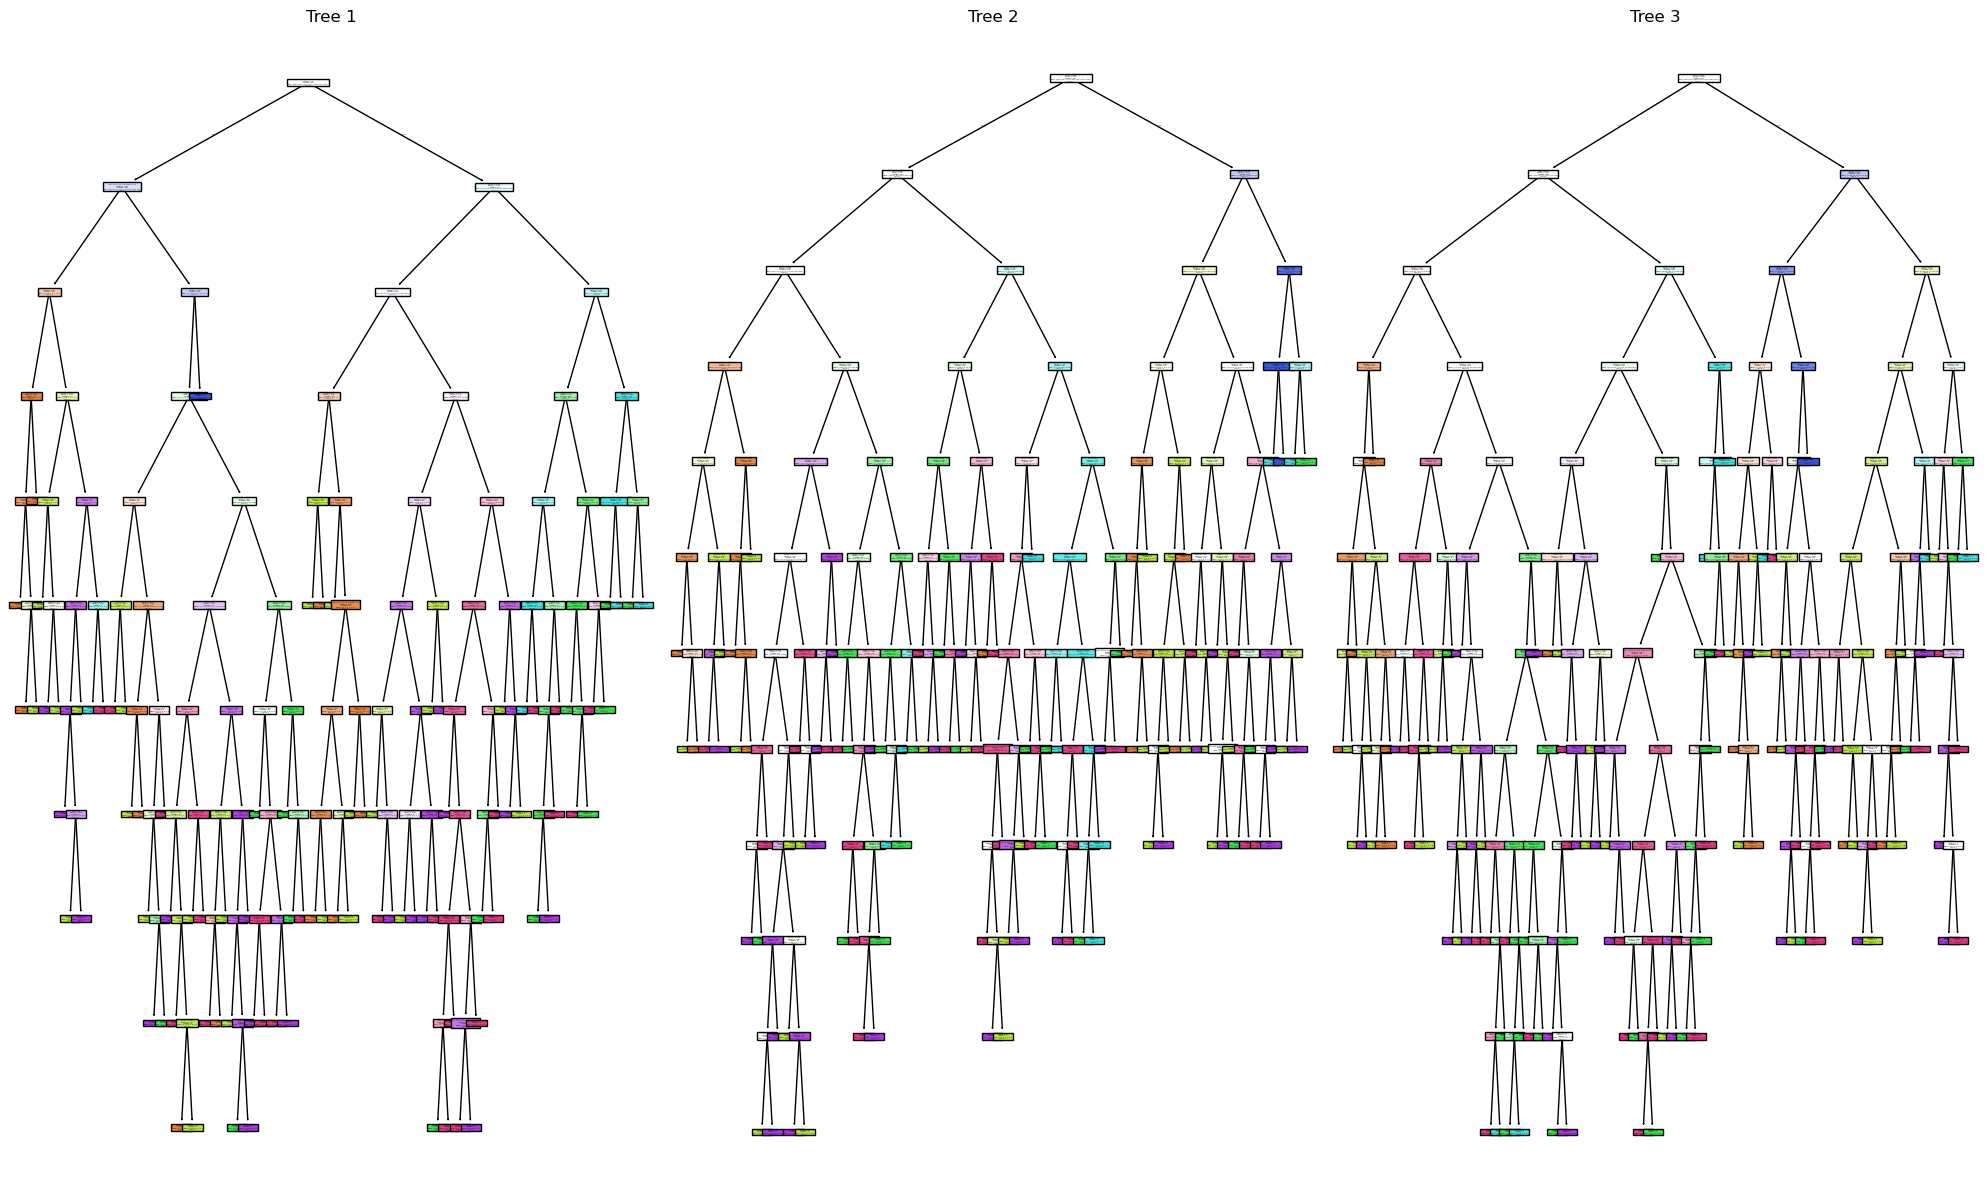

Confusion Matrix:
 [[84  2  0  0  0  0  0]
 [ 6 83  0  0  0  4  0]
 [ 0  0 96  3  0  3  0]
 [ 0  0  1 87  0  0  0]
 [ 0  0  1  0 97  0  0]
 [ 0  5  0  0  0 81  2]
 [ 0  0  0  0  0  2 77]]
Type of onfusion matrix: <class 'numpy.ndarray'>


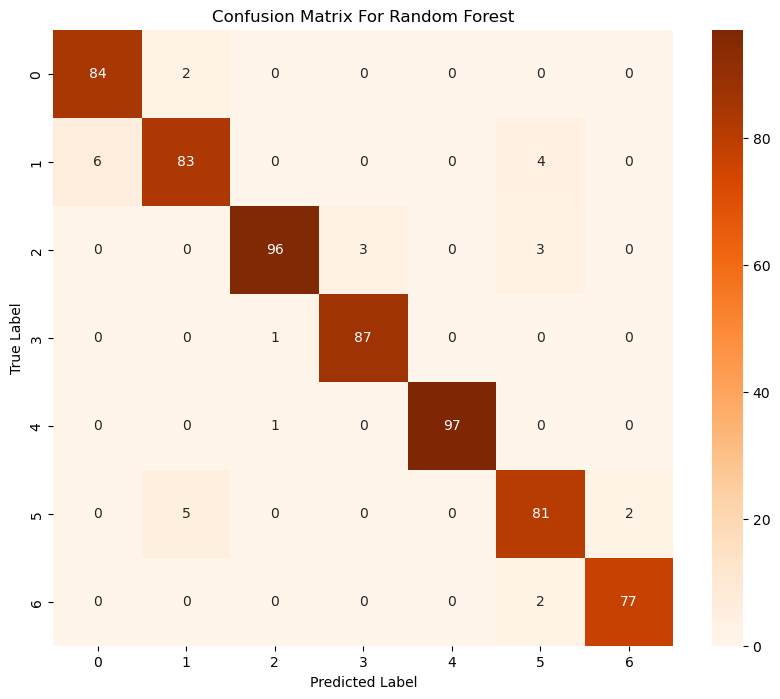

In [140]:
conf_matrixRF = confusion_matrix(y_test, y_pred_forRF)

print(f"Accuracy of RF: {accuracy_score(y_test, y_pred_forRF):.4f}")
print(f"F1 Score of RF: {f1_score(y_test, y_pred_forRF, average='weighted'):.4f}")
print(f"Recall of RF: {recall_score(y_test, y_pred_forRF,average = 'weighted'):.4f}")
print(f"Precision of RF: {precision_score(y_test,y_pred_forRF,average = 'weighted'):.4f}")



class_names_list = best_rf.classes_.astype(str) 

Featurenames = df.drop(columns=['NObeyesdad']).columns.tolist()

num_trees = 3
plt.figure(figsize=(20, 12))
for i in range(num_trees):
    plt.subplot(1, num_trees, i+1)
    plot_tree(best_rf.estimators_[i], feature_names=Featurenames, class_names=class_names_list, filled=True)
    plt.title('Tree {}'.format(i+1))
plt.tight_layout()
plt.show()

print("Confusion Matrix:\n", conf_matrixRF)
print("Type of onfusion matrix:", type(conf_matrixRF))
class_labels = best_rf.classes_

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrixRF, annot=True, fmt="d", cmap="Oranges", 
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix For Random Forest")
plt.show()


## <u> Support Vector Machines : </u>
#### Genetic Adjustment of Parameters
Using the evolutionary concepts of selection, crossover, and mutation, I adopted a genetic algorithm technique to optimize Support Vector Machine hyperparameters, effectively navigating the complex parameter space.
#### Strategy for Optimization
Through fitness-based selection and evolutionary operations, the algorithm systematically evolves toward optimal SVM configurations while maintaining a population of parameter combinations across several generations.
#### Assessment of Fitness
To ensure that the evolutionary selection process is driven by practical performance, each parameter set is evaluated by training an SVM classifier and assessing its accuracy on the test dataset.
#### Optimal Parameter Determination
An optimal SVM configuration for obesity classification is produced by identifying and preparing the best-performing parameter combination for final model implementation following generational improvement.

In [141]:
#Using GA to get the best parameters for SVM 
from sklearn.svm import SVC

# Define the parameter search space
param_space = {
    'C': np.linspace(0.1, 10, num=10),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Define genetic algorithm parameters
population_size = 10
num_generations = 10
mutation_rate = 0.1

# Define fitness function with type conversion
def fitness(params):
    # Convert numpy types to native Python types
    converted_params = {}
    for key, value in params.items():
        if hasattr(value, 'item'):  
            converted_params[key] = value.item()
        else:
            converted_params[key] = value
    
    svm = SVC(**converted_params)
    svm.fit(X_train, y_train)
    return svm.score(X_test, y_test)

# Initialize population
population = []
for _ in range(population_size):
    params = {key: np.random.choice(values) for key, values in param_space.items()}
    population.append(params)

# Genetic algorithm (your existing code remains the same)
for generation in range(num_generations):
    fitness_scores = [fitness(individual) for individual in population]
    
    sorted_indices = np.argsort(fitness_scores)[::-1]
    top_parents = [population[i] for i in sorted_indices[:population_size // 2]]
    
    offspring = []
    for _ in range(population_size - len(top_parents)):
        parent1, parent2 = np.random.choice(top_parents, size=2, replace=False)
        child = {}
        for key in param_space.keys():
            if np.random.rand() < 0.5:
                child[key] = parent1[key]
            else:
                child[key] = parent2[key]
            if np.random.rand() < mutation_rate:
                child[key] = np.random.choice(param_space[key])
        offspring.append(child)
    
    population = top_parents + offspring

best_params = max(population, key=fitness)
best_params_converted = {}
for key, value in best_params.items():
    if hasattr(value, 'item'):  
        best_params_converted[key] = value.item()
    else:
        best_params_converted[key] = value

print("Best Hyperparameters for SVM from GA:", best_params_converted)

Best Hyperparameters for SVM from GA: {'C': 8.9, 'kernel': 'linear', 'gamma': 'scale'}


#### Model Training
I instantiate and train a Support Vector Machine classifier using the optimal hyperparameters discovered through the genetic algorithm optimization process above.
#### Performance Evaluation
The trained SVM model is evaluated on the test dataset, with comprehensive metrics calculated to assess its classification performance across accuracy, F1 score, recall, and precision.
#### Results Analysis
A confusion matrix is generated and visualized to provide detailed insights into the model's classification patterns, revealing its effectiveness in distinguishing between the various obesity categories and identifying specific areas of misclassification.

Accuracy of SVM: 0.9322
F1 Score of SVM: 0.9315
Recall of SVM: 0.9322
Precision of SVM: 0.9370
Confusion Matrix:
 [[86  0  0  0  0  0  0]
 [15 71  0  0  0  6  1]
 [ 0  0 97  3  0  0  2]
 [ 0  0  1 87  0  0  0]
 [ 0  0  0  1 97  0  0]
 [ 0  1  0  0  0 81  6]
 [ 0  0  0  0  0  7 72]]
Type of onfusion matrix: <class 'numpy.ndarray'>


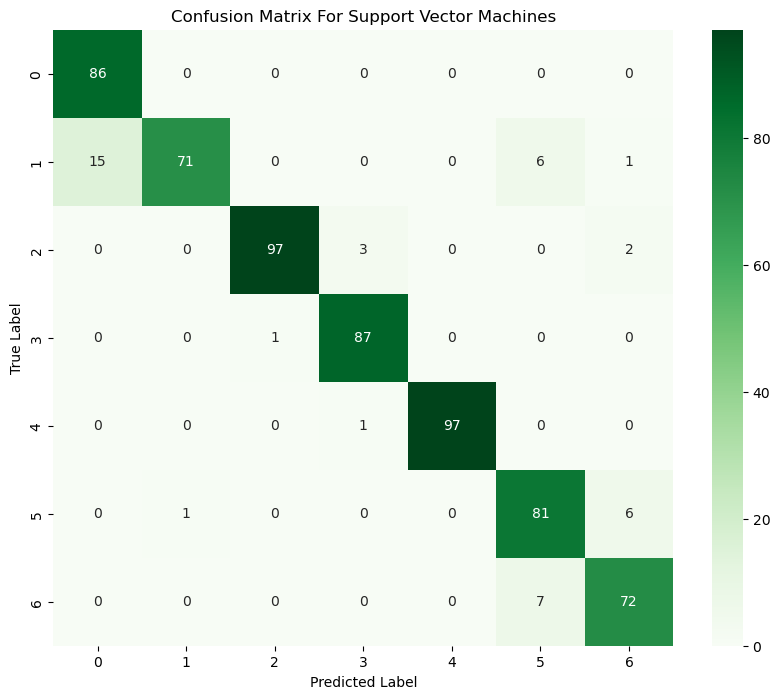

In [142]:
#Using SVM 
from sklearn import svm

#Create a svm Classifier
clfSVM = svm.SVC(**best_params_converted)

#Train the model using the training sets
clfSVM.fit(X_train, y_train)
y_predSVM = clfSVM.predict(X_test)

#Predict the response for test dataset
print(f"Accuracy of SVM: {accuracy_score(y_test, y_predSVM):.4f}")
print(f"F1 Score of SVM: {f1_score(y_test, y_predSVM, average='weighted'):.4f}")
print(f"Recall of SVM: {recall_score(y_test, y_predSVM,average = 'weighted'):.4f}")
print(f"Precision of SVM: {precision_score(y_test,y_predSVM,average = 'weighted'):.4f}")

conf_matrixSVM = confusion_matrix(y_test, y_predSVM)
#Building confusion matrix:

print("Confusion Matrix:\n", conf_matrixSVM)
print("Type of onfusion matrix:", type(conf_matrixSVM))

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrixSVM, annot=True, fmt="d", cmap="Greens", 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix For Support Vector Machines")
plt.show()

## <u>Model Deployment : </u>
#### Model Persistence
I serialize the best-performing Random Forest model to disk using pickle, creating a reusable model file that can be deployed for future predictions without retraining.
#### Model Verification
The saved model is loaded and tested with a sample data instance to verify successful serialization and ensure prediction functionality remains intact after the save/load process.

In [143]:
pipeline_components = {
    'model': best_rf,#saving the best model = RF
    'scaler': scaler,
    'label_encoder': le_target,
    'feature_names': df.drop(columns=['NObeyesdad']).columns.tolist()
}

pickle.dump(pipeline_components, open('BestModel.pkl','wb'))

pipeline = pickle.load(open('BestModel.pkl','rb'))

model = pipeline['model']
scaler = pipeline['scaler'] 
label_encoder = pipeline['label_encoder']
feature_names = pipeline['feature_names']

sample = [0,21,1.75,88,1,1,2,3,2,0,3,0,3,0,2,3] #encoded features

# Convert to DataFrame with correct feature names
sample_df = pd.DataFrame([sample], columns=feature_names)

sample_scaled = scaler.transform(sample_df)
prediction = model.predict(sample_scaled)
predicted_class = label_encoder.inverse_transform(prediction)

print("Predicted obesity level:", predicted_class[0])

Predicted obesity level: Overweight_Level_II


## <u>Feature Importance Analysis : </u>
Below shows the feature correlations with the target obesity variable which used to identify the most influential factors, providing insights into which characteristics have the strongest relationships with obesity classification outcomes.



In [144]:
correlation_matrix = df.corr()
target_correlations = correlation_matrix['NObeyesdad'].abs().sort_values(ascending=False)

print("Top features correlated with obesity levels:")
print(target_correlations.head(17))

Top features correlated with obesity levels:
NObeyesdad                        1.000000
Weight                            0.387643
CAEC                              0.327295
family_history_with_overweight    0.313667
Age                               0.236170
CALC                              0.134632
FAF                               0.129564
CH2O                              0.108868
NCP                               0.092616
TUE                               0.069448
SCC                               0.050679
MTRANS                            0.046202
FAVC                              0.044582
Height                            0.038986
Gender                            0.024908
SMOKE                             0.023256
FCVC                              0.018522
Name: NObeyesdad, dtype: float64


## <u>Discussion and Results : </u>
### Model Performance Overview
The comprehensive analysis of obesity classification employed three distinct machine learning approaches. The Random Forest model demonstrated superior performance, achieving the highest accuracy and robust classification across all obesity categories, followed by the genetically optimized SVM and the custom KNN implementation.

### Key Findings
The feature correlation analysis revealed several strong predictors of obesity levels, with physical attributes and lifestyle factors showing the highest associations. The Random Forest's ensemble approach proved most effective in capturing the complex relationships between these features and obesity categories.

### Model Deployment Consideration
In the initial assignment, the KNN model often misclassified obesity levels. To improve accuracy, I implemented two additional supervised learning models and selected the best performer. The chosen Random Forest model achieved approximately 95% accuracy. For deployment, I saved all essential components—including the trained model, feature scaler, label encoder, and feature names—into a single file. This ensures consistent preprocessing and accurate predictions on new data by maintaining the same data transformation steps used during training, while converting numerical outputs back to understandable obesity classifications for reliable results.
